<h1><center>Laboratorio 4: EDA en Pandas 🐼</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

### Cuerpo Docente:

- Profesores: Pablo Badilla, Diego Cortez
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Patricio Espinoza Acuña.
- Nombre de alumno 2: Javiera Romero Orrego.


### **Link de repositorio de GitHub:** `https://github.com/patricioespinozaa/MDS7202`


## Reglas:

- **Grupos de 2 personas**
- Asistencia **obligatoria** a instrucciones del lab (viernes 16.15). Luego, pueden quedarse trabajando en las salas o irse.
- **No se revisarán entregas de personas ausentes**. 
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias. 
- Pueden usar cualquer matrial del curso que estimen conveniente.

### Objetivos principales del laboratorio

- Aplicar los paradigmas y buenas prácticas de programación vistas hasta este momento.
- Utilizar las funciones de la librería `pandas` para realizar análisis exploratorio de datos
- Aplicar principios de visualización de datos vistos en clases para mostrar patrones en los datos


El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas de `pandas`.

## Descripción del laboratorio.

### Importamos librerias utiles 😸

In [1]:
# Libreria Core del lab.

# Libreria para plotear
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import Markdown, display
from scipy import stats

# Segmentación de Clientes en Tienda de Retail 🛍️

<p align="center">
  <img width=300 src="https://s1.eestatic.com/2018/04/14/social/la_jungla_-_social_299733421_73842361_854x640.jpg">
</p>

## 1.1 Cargar dataset [0.5 puntos]

Mr. Lepin Mora quien es el gerente de una cotizada tienda de retail en Europa, les solicita si pueden analizar los datos de algunas de sus tiendas.

Para esto, el área de ventas les entrega el 2 archivos: `online_retail_II.pickle` y `online_retail_I.pickle`.
- Cargue ambas fuentes y asegúrese que las columnas son del tipo correcto como en el ejemplo de df_retail_1 visualizando los datos para determinar el tipo. Para fechas, puede usar `'datetime64[ns]'`
- Combine los dataframes en uno solo. ¿Qué función debe utilizar en este caso? 
    
    **Respuesta**: Debemos utilizar merge ya que tenemos un identificador común entre ambos datasets, "Invoice". Además utilizamos left join tomando primero al dataset retail 1 ya que si tenemos por ejemplo 5 productos con un mismo Invoice, ya que pertenecen a una misma compra, queremos que queden con la misma fecha indicada en el segundo dataset para dicho Invoice. 

- Señale las columnas que componen el dataset combinado, el tipo de variable presente en cada columna y comente que representa cada una de estas.

    **Respuesta**: todo respondido en el código.

**Respuesta:**

In [2]:
df_retail_1 = pd.read_pickle("online_retail_I.pickle")
df_retail_1 = df_retail_1.astype(
    {
        "Invoice": "category",
        "StockCode": "category",
        "Description": str,
        "Customer ID": "category",
        "Quantity": int,
        "Price": float,
        "Country": "category",
    }
)
df_retail_1.head()

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom


In [3]:
# visualización y tipos de datos del segundo dataset
df_retail_2 = pd.read_pickle("online_retail_II.pickle")
df_retail_2 = df_retail_2.astype(
    {
        "Invoice": "category",
        "InvoiceDate": "datetime64[ns]",
    }
)
df_retail_2.head()

,Invoice,InvoiceDate
0,489434,2009-12-01 07:45:00
1,489435,2009-12-01 07:46:00
2,489436,2009-12-01 09:06:00
3,489437,2009-12-01 09:08:00
4,489438,2009-12-01 09:24:00


In [4]:
# Unir ambos datasets
df_retail = df_retail_1.merge(df_retail_2, on="Invoice", how="left")
df_retail = df_retail.astype(
    {
        "Invoice": "category",  # Número de transacción
        "StockCode": "category",  # Código del producto
        "Description": str,  # Descripción del producto
        "Customer ID": "category",  # ID del cliente
        "Quantity": int,  # Cantidad de productos comprados
        "Price": float,  # Precio unitario del producto
        "Country": "category",  # País del cliente
        "InvoiceDate": "datetime64[ns]",  # Fecha y hora de la compra
    }
)

df_retail.head(10)

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,InvoiceDate
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom,2009-12-01 07:45:00
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom,2009-12-01 07:45:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom,2009-12-01 07:45:00
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,1.65,13085.0,United Kingdom,2009-12-01 07:45:00
6,489434,21871,SAVE THE PLANET MUG,24,1.25,13085.0,United Kingdom,2009-12-01 07:45:00
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,5.95,13085.0,United Kingdom,2009-12-01 07:45:00
8,489435,22350,CAT BOWL,12,2.55,13085.0,United Kingdom,2009-12-01 07:46:00
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,3.75,13085.0,United Kingdom,2009-12-01 07:46:00


## 1.2 Analisís Explotatorio de los Datos [0.5 puntos] 

En base a la primera visualización del dataset, *Don Mora* le solicita que realicen un análisis exploratorio de los datos, para esto les deberán realizar un análisis univariado y multivariado. De la revisión, ustedes deben explicar potenciales anomalías visualizadas y señalar si existe la necesidad de realizar una limpieza de datos.

Explique a que nos referimos con análisis univariable, multivariable y de datos faltantes. ¿Qué beneficios nos otorga estudiar estos datos?. Sea conciso con su respuesta y no escriba mas de 5 líneas para su respuesta.

**Respuesta a la Pregunta:**

> Un análisis univariado corresponde a estudiar las variables del dataset de manera independiente una de otra, identificando propiedades de la categoría en sí, podemos observar outliers o distribuciones de la columna. El análisis multivariado nos permite identificar comportamientos conjuntos de las variables del dataset, viendo como interactuan entre ellas. Por último el análisis de datos faltantes, tal como indica su nombre, nos permite ver qué datos faltan, esto nos puede ayudar a validar si es factible continuar trabajando con estos datos, ya sea imputando o eliminando columnas problematicas, O si podría llegar a sesgar los resultados de un análisis o modelamiento generando que el problema no sea abordable. 

### 1.2.1 Análisis Univariado [1.5 Puntos]

A continuación, se le presentan dos funciones para analizar los datos que componen un dataframe. La primera de estas es la función ``profile_serie()`` la cual recibe una serie y le entrega un análisis detallado de los datos que conforman dicha serie. 

Ejecute la funcion ``profile_serie()`` sobre cada serie para realizar un análisis univariado de estas. A continuación, comente acerca de el comportamiento de cada variable según las estadísticas descriptivas y los gráficos generados.

In [5]:
from pandas.api.types import is_datetime64_any_dtype, is_numeric_dtype, is_timedelta64_dtype


def profile_serie(serie_in, n_samples=1000, random_state=42):
    serie = serie_in.copy()

    profile = pd.Series(dtype="object")
    profile["Type"] = serie.dtype
    profile = pd.concat([profile, serie.describe()])

    # profile = pd.Series([])

    if is_numeric_dtype(serie):
        profile["Negative"] = (serie < 0).sum()
        profile["Negative (%)"] = str(round((serie < 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Zeros"] = (serie == 0).sum()
        profile["Zeros (%)"] = str(round((serie == 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Kurt"] = serie.kurt()
        profile["Skew"] = serie.skew()

    profile[" "] = " "  # espacio

    profile["Missing cells"] = serie.isnull().sum()
    profile["Missing cells (%)"] = str(round(serie.isnull().sum() / len(serie) * 100, 2)) + " %"
    profile["Duplicate rows"] = serie.duplicated(False).sum()
    profile["Duplicate rows (%)"] = str(round(serie.duplicated(False).sum() / len(serie) * 100, 2)) + " %"
    profile["Total size in memory"] = str(serie.memory_usage(index=True)) + " bytes"

    # profile = pd.concat([profile, description])

    profile = profile.rename(
        index={
            "count": "Number of observations",
            "mean": "Mean",
            "std": "Std",
            "min": "Min",
            "max": "Max",
            "unique": "Unique",
            "top": "Top",
            "freq": "Freq",
        }
    )
    no_outliers_fig = None

    if is_numeric_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name} - With Outliers")

        no_outliers = sampled_serie.loc[(np.abs(stats.zscore(sampled_serie)) < 3)]
        # zscore = https://es.wikipedia.org/wiki/Unidad_tipificada

        no_outliers_fig = px.histogram(no_outliers, marginal="box", title=f"{serie.name} - Without Outliers")

    elif is_datetime64_any_dtype(serie) or is_timedelta64_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}")

    else:
        count = serie.value_counts()[0:100].reset_index().rename(columns={"count": "Count"})
        fig = px.bar(
            x=count[serie.name].astype(str),
            y=count["Count"],
            title=f"100 Most common categories of {serie.name}",
        )
    display(Markdown(f"## {serie.name} Profile"))
    display(profile)
    fig.show()

    if no_outliers_fig:
        no_outliers_fig.show()

    # return fig, profile

In [6]:
profile_serie(df_retail["Price"])

## Price Profile

Type                            float64
Number of observations         525461.0
Mean                           4.688834
Std                          146.126914
Min                           -53594.36
25%                                1.25
50%                                 2.1
75%                                4.21
Max                            25111.09
Negative                              3
Negative (%)                      0.0 %
Zeros                              3687
Zeros (%)                         0.7 %
Kurt                       64868.344873
Skew                        -140.768446
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   524485
Duplicate rows (%)              99.81 %
Total size in memory      4203820 bytes
dtype: object

    Podemos notar claramente como los outliers afectan el comportamiento general de la variable, al quitarlos también podemos observar una curva mucho más cercana a una distribución normal. Notamos también que el valor minimo en la variable es -53594.36, lo cual no tiene sentido en la vida real, los precios no deberían ser negativos, de manera similar se nos indica que hay 3 valores negativos en total en los datos los cuales deberían ser eliminados. A su vez notamos una alta cantidad de valores iguales a 0, 3687 para ser exactos, esto tampoco tiene mucho sentido en la práctica por lo que deberían ser tratados. Finalmente vemos relevante que hay una gran cantidad de valores repetidos, 524485, esto si tiene sentido con la realidad, sabemos que por ejemplo la mayoría de los precios terminan en 990.

    Por otra parte, a partir del resultado de Skew podemos ver la asimetría en la distribución, en este caso, el Skew negativo de -140.76 indica que hay una asimetria en donde la cola esta cargada hacia la izquierda lo cual puede ser ocasionado por los valores extremos como -53594.36.

    En cuanto a Kurt, podemos saber que tan pesadas son las colas y que tan concentrada en un peak esta la distribución. En este caso, el valor de 64868.34 indica que hay outliers muy extremos que extienden las colas de la distribución.

In [7]:
profile_serie(df_retail["Quantity"])

## Quantity Profile

Type                              int64
Number of observations         525461.0
Mean                          10.337667
Std                           107.42411
Min                             -9600.0
25%                                 1.0
50%                                 3.0
75%                                10.0
Max                             19152.0
Negative                          12326
Negative (%)                     2.35 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                        6277.666908
Skew                          36.044617
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   525122
Duplicate rows (%)              99.94 %
Total size in memory      4203820 bytes
dtype: object

    A partir de las observaciones descriptivas se puede observar que existen 12326 (2.35%) datos negativos en Quantity, lo cual representa un tipo de anomalía. Por otra parte, no hay información faltante en este campo respecto a las transacciones.

    En particular, el promedio de compras de un mismo producto es de 10.33, con algunas excepciones mayores que provcan la desviación estándar obtenida (107.42). Esto mismo se puede observar a partir de los gráficos, en donde la gran mayoría de compras de un mismo item se concentran en cantidades del rango [1, 15].

    Además, del análisis de outliers se observan casos muy aislados de compras de un mismo item en grandes cantidades, las cuales se salen de la norma del negocio (cantidades por sobre 200). Estas pueden ser indicativos de compras mayoristas, o directamente de errores de tipeo al realizar las compras.

    En cuanto al valor obtenido de Skew, 36.04, podemos ver que es positivo, indicando por tanto una cola que está cargada hacia el lado derecho. Por otra parte, se obtuvo un valor de Kurt de 6277.67, indicando que las colas son pesadas y con una presencia fuerte de outliers, esto genera que la distribción original se aleja de la normal y en su lugar pasa a ser dominada por los outliers (valores extremos).

In [8]:
profile_serie(df_retail["InvoiceDate"])

## InvoiceDate Profile

Type                                     datetime64[ns]
Number of observations                           525461
Mean                      2010-06-28 11:37:36.619958528
Min                                 2009-12-01 07:45:00
25%                                 2010-03-21 12:20:00
50%                                 2010-07-06 09:51:00
75%                                 2010-10-15 12:45:00
Max                                 2010-12-09 20:01:00
                                                       
Missing cells                                         0
Missing cells (%)                                 0.0 %
Duplicate rows                                   520408
Duplicate rows (%)                              99.04 %
Total size in memory                      4203820 bytes
dtype: object

    Los duplicados en este grafico representan las transacciones que se han hecho a una misma hora. Además, observando la serie temporal es posible ver que existen picos de compras, permitiendo inferir que existen eventos como el Black Friday (el cual ocurre el 27 de noviembre a partir del año 2010 en UK) o festivos. Asimismo, se nota una tendencia sostenida a la alza en las trasacciones a lo largo del tiempo, lo cual puede indicar un crecimiento en las ventas. 

In [9]:
profile_serie(df_retail["Country"])

## Country Profile

Type                            category
Number of observations            525461
Unique                                40
Top                       United Kingdom
Freq                              485852
                                        
Missing cells                          0
Missing cells (%)                  0.0 %
Duplicate rows                    525461
Duplicate rows (%)               100.0 %
Total size in memory        526985 bytes
dtype: object

    De esta información se puede ver que han habido transacciones desde 40 países distintos, en donde los principales son aquellos en Europa, lo cual tiene sentido con el enunciado. Además, se infiere que esta es originaria del Reino Unido y se centran en la importación y no tanto en la exportación a otros paises.

In [10]:
profile_serie(df_retail["Description"])

## Description Profile

Type                                                     str
Number of observations                                522533
Unique                                                  4681
Top                       WHITE HANGING HEART T-LIGHT HOLDER
Freq                                                    3549
                                                            
Missing cells                                           2928
Missing cells (%)                                     0.56 %
Duplicate rows                                        525198
Duplicate rows (%)                                   99.95 %
Total size in memory                           4203820 bytes
dtype: object

    A partir del analísis de descripciones comunes es posible observar que varios items tienen la misma descripción, y por tanto implica que son aquellos más solicitados. Además, es importante ver si coinciden las frecuencias en apariciones de las descripciones con la de los items (StockCode). En caso de no coincidir, esto sería un indicio de que las descripciones han ido cambiando con el tiempo, afectando el recuento en este histograma.


In [11]:
profile_serie(df_retail["Customer ID"])

## Customer ID Profile

Type                           category
Number of observations         417534.0
Unique                           4383.0
Top                             14911.0
Freq                             5710.0
                                       
Missing cells                    107927
Missing cells (%)               20.54 %
Duplicate rows                   525327
Duplicate rows (%)              99.97 %
Total size in memory      1086118 bytes
dtype: object

    Este histograma permite observar que hay una gran diferencia en la tendencia de compras de los usuarios, en donde la mayoría ha realizado compras por menos de 1.000 items (puede ser una grande de distintos items, o varias transacciones pequeñas)
    Por otro lado, destaca que unos pocos usuarios han realizado compras por sobre los 2.000 items.

    Asimismo, se puede ver que se tienen 4383 usuarios identificados (CustomerID) pero también hay 107927 celdas vacias, lo que representa una gran cantidad de información faltante y que podría ser util para analísis o modelos de recomendación de items.

    Esto puede ser un indicativo de que, en caso de ser una tienda presencial, una gran cantidad de usuarios no están registrados y por tanto la compra se finaliza solo con la transacción. Por otra parte, si esta tienda tiene unicamente sitio web, puede que aquellos usuarios sin CustomerID hayan finalizado su transacción con solo el requerimiento de lugar de despacho y método de pago.

In [12]:
profile_serie(df_retail["StockCode"])

## StockCode Profile

Type                           category
Number of observations           525461
Unique                             4632
Top                              85123A
Freq                               3516
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   525026
Duplicate rows (%)              99.92 %
Total size in memory      1220246 bytes
dtype: object

    De este histograma se pueden obtener los items más comprados en la historia de la empresa, se remarca como hay una clara diferencia entre el primero que esta presente en 3516 transacciones, y el segundo que esta presente en 2221.

    Por otra parte, resulta interesante ver que existen 4632 items únicos, es decir, que fueron comprados una única vez. Esto representa una oportunidad interesante de analizar en cuanto a métricas del negocio para saber la razón detrás de esto.

In [13]:
profile_serie(df_retail["Invoice"])

## Invoice Profile

Type                           category
Number of observations           525461
Unique                            28816
Top                              537434
Freq                                675
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   517456
Duplicate rows (%)              98.48 %
Total size in memory      2338390 bytes
dtype: object

    A partir de los códigos de Invoice (transacciones), se observa que una misma compra puede incluir varios tipos de productos distintos. La transacción con mayor variedad reúne 700 ítems diferentes, mientras que la última dentro del top 100 alcanza 256. Esto sugiere que, aunque no se trate necesariamente de compras mayoristas de un solo producto en gran volumen, sí existen compras de alta magnitud en términos de diversidad de artículos.

    En el mismo ámbito, del total de 525461 observaciones, tan solo 28816 son únicas, lo que indica que la mayoría de las transacciones incluye, al menos, más de un ítem distinto (un mismo item aumenta en quantity dentro de su misma fila).

### 1.2.2 Análisis Multivariado y Datos Faltantes [1 ptos]

En segundo lugar encontrará la función ``profile_df()`` que recibe un dataframe como entrada y realiza un análisis bivariado de todas las variables numéricas que conforman el dataframe, un analisis de la correlación de Pearson entre las variables numericas del dataframe y la matriz de datos faltantes.

Utilice esta función en el dataframe. Comente sobre los patrones que observa. Luego responda:
- Existen correlaciones relevantes observadas?
- Qué aspectos revelan estos gráficos acerca de la limpieza de los datos?

In [14]:
def profile_df(dataframe_in):
    df = dataframe_in.copy()

    list_type = []
    for col in list(df.columns):
        if is_numeric_dtype(df[col]) or is_datetime64_any_dtype(df[col]) or is_timedelta64_dtype(df[col]):
            list_type.append(col)

    display(Markdown("## Bivariant Analysis:"))
    for i in range(len(list_type)):
        for j in range(i + 1, len(list_type)):
            plt.scatter(df[list_type[i]], df[list_type[j]])
            plt.xlabel(list_type[i])
            plt.ylabel(list_type[j])
            plt.title(f"{list_type[i]} v/s {list_type[j]}")
            plt.show()

    display(Markdown("## Correlation:"))
    fig_corr = px.imshow(df[list_type].corr())
    fig_corr.show()

    display(Markdown("## Missing Matrix:"))
    fig, ax = plt.subplots(figsize=[15, 10])
    msno.matrix(df, ax=ax, sparkline=False)

- Existen correlaciones relevantes observadas?
- Qué aspectos revelan estos gráficos acerca de la limpieza de los datos?

Quantity vs Price:

    No es posible observar una correlación relevante entre Quantity y Price debido a las magnitudes presentes en el gráfico. Sería adecuado observarlo posterior a una limpieza para tener una mejor visualización.
    
    Además, es posible observar que las cantidades son transversales para el rango [0, 5] de Price, mientras que para aquellos precios elevados las cantidades de compras disminuyen considerablemente.

    Si bien no es claramente observable, esperamos que luego de una limpieza sería posible visualizar algún tipo de relación inversa entre el precio y la cantidad (mayor cantidad a menor precio) debido a que se tratan de precios de Retail.

    Respecto a los outliers, es posible ver como existen para aquellos items de precios elevados, o aquellas transacciones muy grandes (Quantity).


Quantity vs InvoiceDate

    Debido a los datos brutos con anomalias no es posible observar una clara correlación entre InvoiceDate y Quantity, sin embargo, si existen ciertos peaks de compras en grandes cantidades presentes para los meses entre enero-marzo, agosto y octubre/noviembre. 
    
    Para el resto del año se puede observar que existe una base de compras siempre presente para cantidades menores que va variando periodicamente (en el período 2010-01, 2010-03 y 2010-05 se puede observar como hay altos y bajos en las tendencias de compras base).

    A partir de este grafico se puede observar que a lo largo del tiempo han ocurrido transacciones con cantidades negativas lo cual indica anomalias. Además, se puede ver que conforme aumentan los meses, dichas cantidad negativas aumentan en magnitud.


Price vs InvoiceDate

    En este caso si bien tampoco es posible observar una correlación clara entre Price e InvoiceDate, si es posible ver que la base de precios se mantiene constante a lo largo del tiempo puesto que se trata de una tienda de Retail. 

    Por otra parte, también se observa que aquellas compras de items con precios elevados pareciera coincidir con el gráfico anterior, en donde ocurren los peaks en cantidades de compras.

    En cuanto a datos anomalos, es posible ver tres valores negativos de precios los cuales deberian ser removidos (presentes también en el analísis univariado de Price), mientras que aquellos precios elevados parecieran ser outliers.

Consideramos que en estas visualizaciones, si bien no es posible verificar correlaciones claras, el ruido generado por los datos anomalos y outliers no favoreció a una mejor visualización y que por tanto deberia ser repetida con estas consideraciones.

Correlation Matrix

    Para la matriz de correlación es posible observar como las variables númericas no tienen correlaciones positivas entre sí y todas suelen ser ligeramente negativas.

    Este gráfico debería ser realizado luego de una limpieza para observar si el tratamiento de los datos anomalos representa una mejora en este analísis.

Missing Matrix

    A partir de la Missing Matrix es posible ver que hay algunos datos faltantes en la columna de Description y principalmente en la de CustomerID lo cual puede ser debido a su analísis univariado. Por tanto, es posible decir que no hay complicaciones para utilizar el dataset debido a que hay gran completitud/cobertura en las columnas principales.

## Bivariant Analysis:

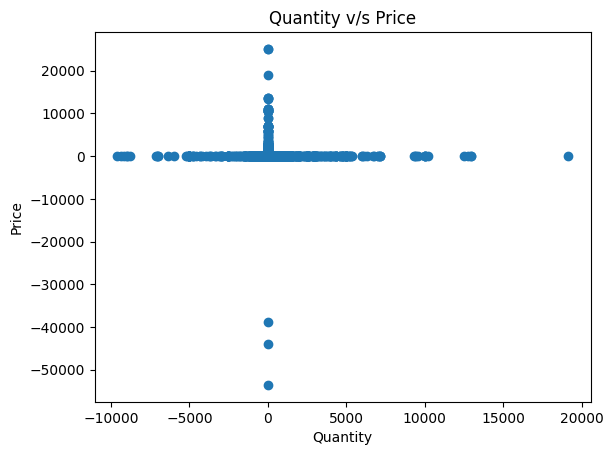

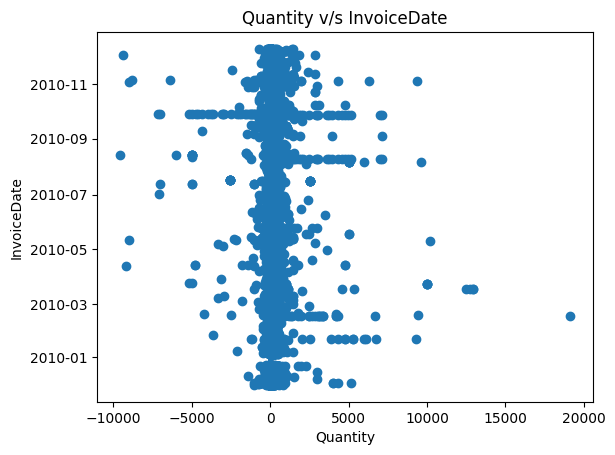

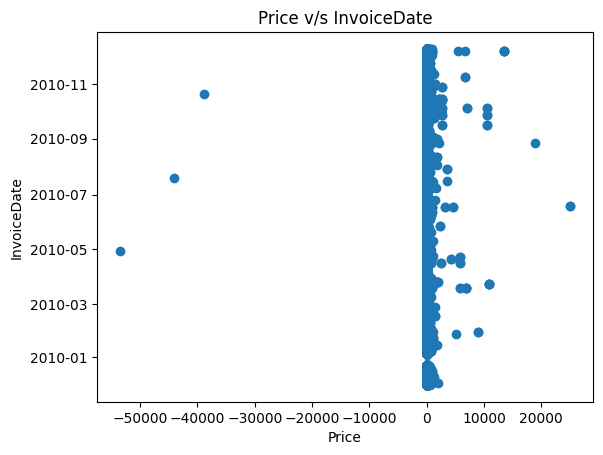

## Correlation:

## Missing Matrix:

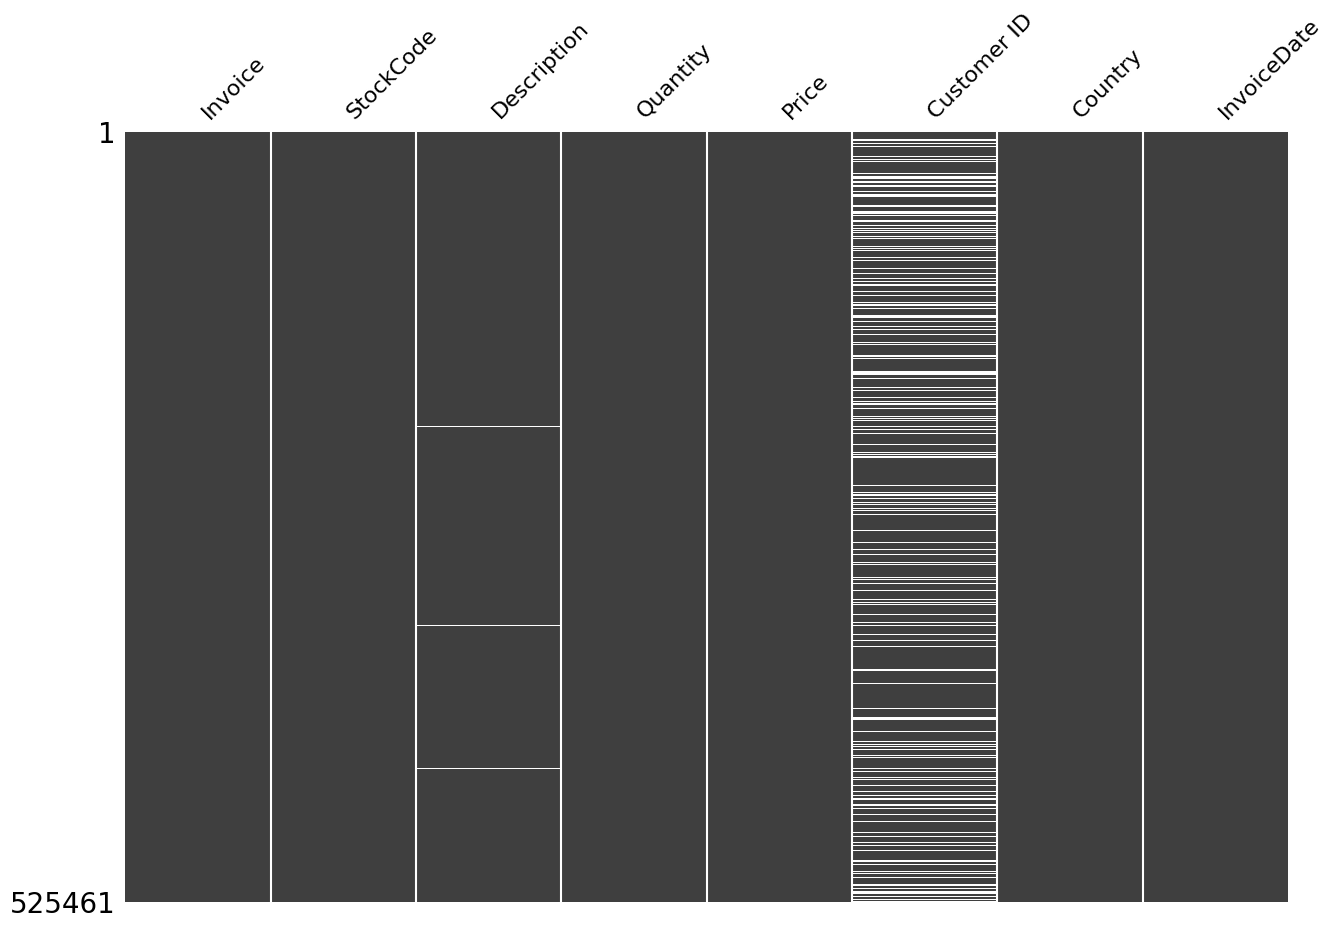

In [15]:
profile_df(df_retail)

### 1.2.3 Limpieza de Datos [1 pto]

Como pudo ver en las secciones anteriores, los datos presentan valores erroneos, es por esto que se le solicita que realice una función que permita limpiar el dataset. Realice esta función en base observaciones propias y considere como **imposible tener cantidades negativas** en las ventas. Investigue sobre métodos para eliminar outliers usando pandas

Una vez realizada la función, realice nuevamente el análisis exploratorio y comente las principales diferencias.

**Respuesta:**

In [16]:
def clean_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df_cleaned = df.copy()

    # Eliminar filas con valores no validos para ventas
    df_cleaned = df_cleaned[(df_cleaned["Quantity"] > 0) & (df_cleaned["Price"] > 0)]

    x_price = 20
    x_quantity = 30

    # Eliminar outliers de price usando x_price
    df_cleaned = df_cleaned[df_cleaned["Price"] < x_price]

    # Eliminar outliers de quantity usando x_quantity
    df_cleaned = df_cleaned[df_cleaned["Quantity"] < x_quantity]

    return df_cleaned

In [17]:
df_cleaned = clean_dataframe(df_retail)

Univariable:

    Las diferencias más notorias son que en los analísis de las variables univariables los comportamientos y distribuciones son más observables directamente debido a la eliminación de outliers y tratamiento de datos anomalos.

In [18]:
profile_serie(df_cleaned["Invoice"])
profile_serie(df_cleaned["StockCode"])
profile_serie(df_cleaned["Description"])
profile_serie(df_cleaned["Quantity"])
profile_serie(df_cleaned["Price"])
profile_serie(df_cleaned["Customer ID"])
profile_serie(df_cleaned["Country"])
profile_serie(df_cleaned["InvoiceDate"])

## Invoice Profile

Type                           category
Number of observations           479742
Unique                            19239
Top                              537434
Freq                                658
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   478221
Duplicate rows (%)              99.68 %
Total size in memory      6084756 bytes
dtype: object

## StockCode Profile

Type                           category
Number of observations           479742
Unique                             4169
Top                              85123A
Freq                               2760
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   479569
Duplicate rows (%)              99.96 %
Total size in memory      4966612 bytes
dtype: object

## Description Profile

...

Type                           category
Number of observations         380304.0
Unique                           4164.0
Top                             14911.0
Freq                             5146.0
                                       
Missing cells                     99438
Missing cells (%)               20.73 %
Duplicate rows                   479681
Duplicate rows (%)              99.99 %
Total size in memory      4832484 bytes
dtype: object

## Country Profile

Type                            category
Number of observations            479742
Unique                                40
Top                       United Kingdom
Freq                              446635
                                        
Missing cells                          0
Missing cells (%)                  0.0 %
Duplicate rows                    479742
Duplicate rows (%)               100.0 %
Total size in memory       4319070 bytes
dtype: object

## InvoiceDate Profile

Type                                     datetime64[ns]
Number of observations                           479742
Mean                      2010-06-29 02:52:41.661017856
Min                                 2009-12-01 07:45:00
25%                                 2010-03-21 14:04:00
50%                                 2010-07-07 11:17:00
75%                                 2010-10-17 13:28:00
Max                                 2010-12-09 20:01:00
                                                       
Missing cells                                         0
Missing cells (%)                                 0.0 %
Duplicate rows                                   478433
Duplicate rows (%)                              99.73 %
Total size in memory                      7675872 bytes
dtype: object

Bivariable

    1. En el analísis bivariable entre quantity y price se puede observar que la mayoria de transacciones de un item aumenta su cantidad a medida que el precio es menor, indicando algun grado de correlación negativa entre estas variables.

    2. En el grafico de Quantity vs InvoiceDate se puede observar que a lo largo de los meses la tendencia de compra de items para cantidades menores a 15-20 se mantiene constante, lo que es acorde a un negocio de tipo retail. Además, si bien no se conoce la razón exacta, se puede observar que para los primeros meses del 2010 suelen haber saltos entre las cantidades de compra, mientras que para meses como noviembre estan son transversales a cualquier unidad de cantidad, lo que refuera nuestra hipotesis de ocurrencias temporales como el Black Friday en noviembre de 2010 en UK. 

    3. Del grafico bivariable entre Price e InvoiceDate se puede observar que los precios se mantienen en el mismo rango de ]0, 20] durante todo el año, lo que muestra su invariabilidad en el mercado de retail.

    4. De la matriz de Correlación podemos observar que ahora existe una mejor justificación para la correlación -0.2 de Quantity vs Price. Además, ahora existe una leve correlación positiva entre Quantity e InvoiceDate posiblemente debido a eventos y series temporales, mientras que Price mantiene la correlación negativa con InvoiceDate.

    5. Como observación adicional hipotetizamos que un analísis más profundo consistiría en distinguir por categoría de productos para las fechas. El análisis actualmente realizado sigue siendo muy general y provoca ruido entre que productos son más solicitados en cada período.

## Bivariant Analysis:

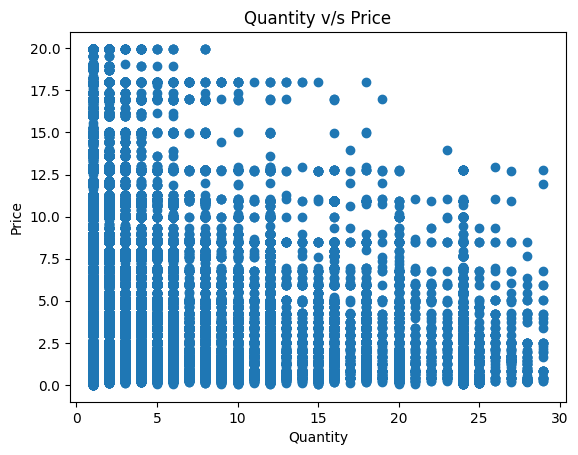

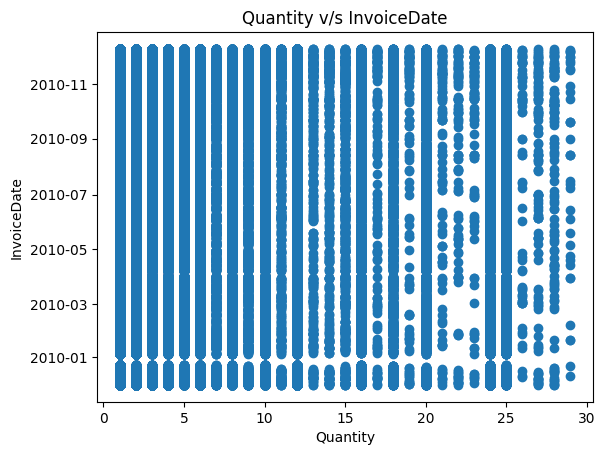

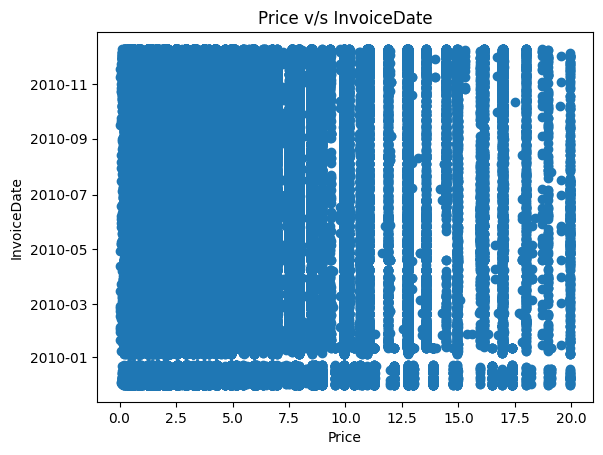

## Correlation:

## Missing Matrix:

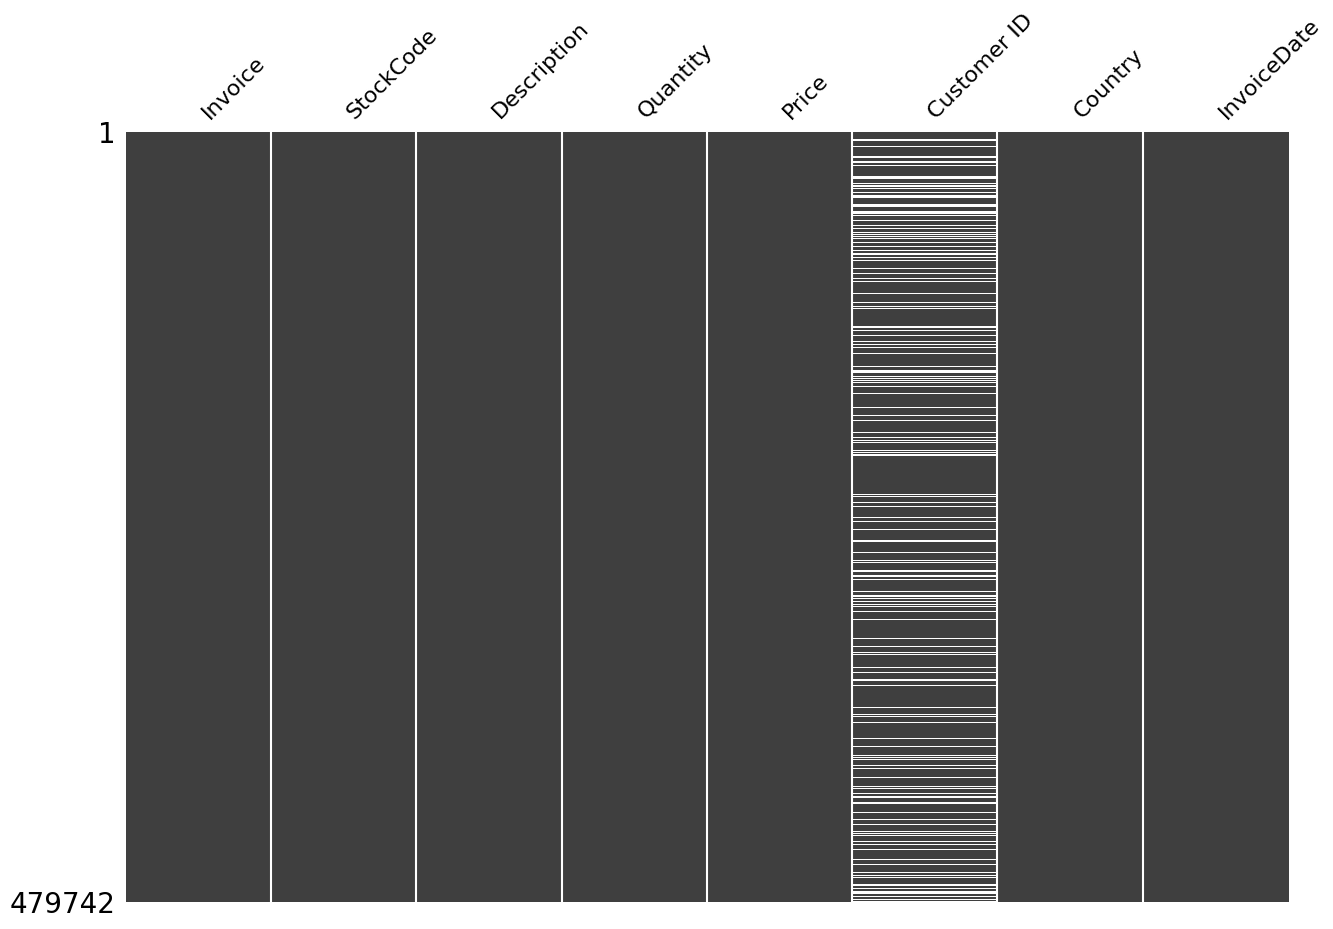

In [19]:
profile_df(df_cleaned)

### 1.2.4 Obtención de TOPs [0.75 ptos]

Sin considerar los comentarios realizados en la sección 1.2 , *Don Mora* les pide obtener el **Top de 30 productos que generan más ganancias** para la tienda de retail. Deben considerar todo el registro temporal presente en el dataset y entregar la información en un gráfico de barras de los ingresos/cantidades v/s el nombre de los productos (Utilice `plotly`). ¿Los artículos más vendidos son los mismos que generan más ganancias?, Comente los resultados obtenidos.

**Resultados:**

A partir del grafico podemos observar que aquellos más vendidos (mayor Cantidad/Quantity en rojo) no necesariamente son siempre los que generan mayores ganancias sino que  aquellos que se venden poco pero tienen un precio mayor tambien están dentro de los primeros lugares en recaudación de ingresos (Cantidad * precio).

Por tanto, la relación entre decir que un árticulo que se vende más será con seguridad el que genere más ganancias no es necesariamente cierta para este negocio.

In [20]:
# Calcular las ganancias por producto
df_retail["Ganancia"] = df_retail["Quantity"] * df_retail["Price"]

# Agrupar por producto y calcular las métricas necesarias
top_products = (
    df_retail.groupby("Description")
    .agg(Ganancia=("Ganancia", "sum"), Cantidad=("Quantity", "sum"))
    .sort_values(by="Ganancia", ascending=False)
    .head(30)
    .reset_index()
)

# gráfico de barras con plotly
fig = px.bar(
    top_products,
    x="Description",
    y=["Ganancia", "Cantidad"],
    barmode="group",
    title="Top 30 Productos por Ganancias",
    labels={"value": "Cantidad / Ganancias", "Description": "Producto"},
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

### 1.2.5 Visualización del registro temporal [0,75 ptos]

El dueño del retail en su afán por saber más sobre los datos de su firma les solicita que grafiquen las ventas respecto al tiempo. Con esto les aclara que durante el día tienen muchas variaciones en sus ventas, por lo que les recomienda que consideren el registro temporal como `año-mes-día`. ¿Es posible observar datos extraños?, Comente lo que observa del gráfico.

In [21]:
def plot_ventas(dataframe):
    # Crear una nueva columna con el formato año-mes-día
    dataframe["Fecha"] = dataframe["InvoiceDate"].dt.date

    # Agrupar las ventas por fecha
    ventas_por_fecha = dataframe.groupby("Fecha").agg({"Quantity": "sum"}).reset_index()

    # Crear el gráfico de líneas
    fig = px.line(
        ventas_por_fecha,
        x="Fecha",
        y="Quantity",
        title="Ventas Diarias en el Tiempo",
        labels={"Quantity": "Cantidad Vendida", "Fecha": "Fecha"},
        markers=True,
    )
    fig.show()


plot_ventas(df_cleaned)

Del grafico de ventas diarias agrupadas por mes podemos observar que para diciembre de 2009 tuvo varios dias con grandes ventas, con un descenso durante las semanas después navidad/año nuevo, posterior a ellas tuvo un ritmo de ventas consiste por día. 

Para cada uno de los meses en el periodo de Marzo a Julio se puede observar la misma tendencia y con peaks de ventas en ciertos días.

Además, desde septiembre a noviembre se puede observar una tendencia al alza en ventas, alcanzando su peak durante varios días de noviembre, el cual puede estar relacionado con la preparación para fechas importantes (Black Friday u ofertas para items de navidad/año nuevo incluso). Durante el mes de Diciembre se observa una disminución en ventas para la primera semana, aunque mayor a otros meses. Asimismo, como no se tienen los datos completos de Diciembre, se podría esperar una nueva tendencia al aumento en ventas basandonos en los datos de Diciembre 2009.

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

![Gracias Totales!](https://i.pinimg.com/originals/65/ae/27/65ae270df87c3c4adcea997e48f60852.gif "bruno")


<br>
<center>
<img src="https://i.kym-cdn.com/photos/images/original/001/194/195/b18.png" width=100 height=50 />
</center>
<br>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>